# Fase 1: Persiapan & Eksplorasi Data

## Instalasi Library

In [1]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.1 MB/s eta 0:00:00


## Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import urllib.request

## Download dan ekstrak dataset

In [3]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
urllib.request.urlretrieve(url, "ml-100k.zip")

with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
  zip_ref.extractall(".")

print("Dataset berhasil diunduh dan diekstrak!")

Dataset berhasil diunduh dan diekstrak!


## Load Data Rating & Film

In [4]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    usecols=[0, 1],
    names=["movie_id", "title"]
)

print(ratings.head())
print(movies.head())

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
   movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995)


## Cek Ukuran & Struktur Data

In [5]:
print(f"Jumlah rating : {len(ratings)}")
print(f"Jumlah user   : {ratings["user_id"].nunique()}")
print(f"Jumlah film   : {ratings["movie_id"].nunique()}")
print("\nInfo ratings :")
print(ratings.info())
print("\nInfo movies  :")
print(movies.info())

Jumlah rating : 100000
Jumlah user   : 943
Jumlah film   : 1682

Info ratings :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Info movies  :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  1682 non-null   int64 
 1   title     1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB
None


## Cek Missing Values

In [6]:
print("Missing values di ratings:")
print(ratings.isnull().sum())

print("\nMissing values di movies:")
print(movies.isnull().sum())

Missing values di ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values di movies:
movie_id    0
title       0
dtype: int64


## Statistik Deskriptif Rating

In [7]:
print("Statistik rating:")
print(ratings["rating"].describe())

print(f"\nRentang rating : {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Rata-rata rating : {ratings['rating'].mean():.2f}")

Statistik rating:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Rentang rating : 1 - 5
Rata-rata rating : 3.53


## Visualisasi Distribusi Rating

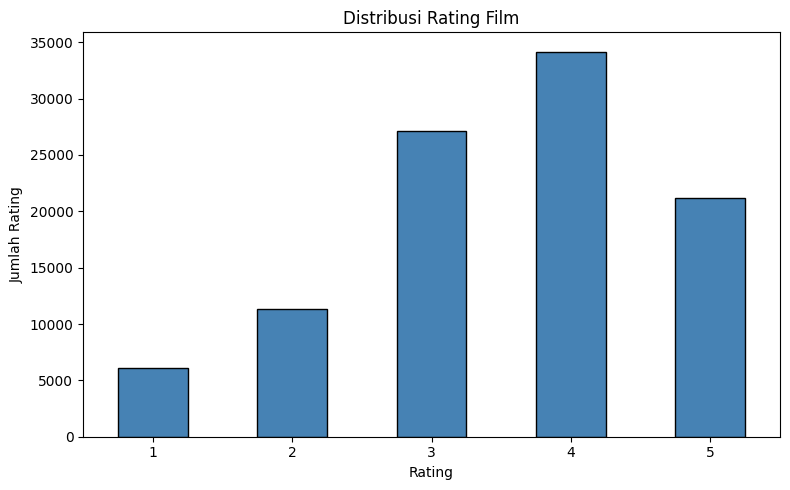

In [12]:
plt.figure(figsize=(8, 5))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribusi Rating Film")
plt.xlabel("Rating")
plt.ylabel("Jumlah Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Penggabungan Data Rating & Judul Film

In [13]:
merged_df = pd.merge(ratings, movies, on="movie_id")
print(merged_df.head(10))

   user_id  movie_id  rating  timestamp  \
0      196       242       3  881250949   
1      186       302       3  891717742   
2       22       377       1  878887116   
3      244        51       2  880606923   
4      166       346       1  886397596   
5      298       474       4  884182806   
6      115       265       2  881171488   
7      253       465       5  891628467   
8      305       451       3  886324817   
9        6        86       3  883603013   

                                               title  
0                                       Kolya (1996)  
1                           L.A. Confidential (1997)  
2                                Heavyweights (1994)  
3                         Legends of the Fall (1994)  
4                                Jackie Brown (1997)  
5  Dr. Strangelove or: How I Learned to Stop Worr...  
6                   Hunt for Red October, The (1990)  
7                            Jungle Book, The (1994)  
8                              

## Menampilkan Film dengan Rating Terbanyak

In [14]:
top_rated_movies = (
    merged_df.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print("10 Film dengan jumlah rating terbanyak:")
print(top_rated_movies)

10 Film dengan jumlah rating terbanyak:
title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64


# Fase 2: Content-Based Filtering

## Load Data Film Beserta Genre

In [15]:
genre_columns = [
    "unknown", "Action", "Adventure", "Animation", "Childrens",
    "Comedy", "Crime", "Documentary", "Fantasy",
    "Horror", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western", "FilmNoir", "Musical", "Drama"
]

movies_with_genres = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + genre_columns
)

print(movies_with_genres[["movie_id", "title"] + genre_columns].head())

   movie_id              title  unknown  Action  Adventure  Animation  \
0         1   Toy Story (1995)        0       0          0          1   
1         2   GoldenEye (1995)        0       1          1          0   
2         3  Four Rooms (1995)        0       0          0          0   
3         4  Get Shorty (1995)        0       1          0          0   
4         5     Copycat (1995)        0       0          0          0   

   Childrens  Comedy  Crime  Documentary  ...  Horror  Mystery  Romance  \
0          1       1      0            0  ...       0        0        0   
1          0       0      0            0  ...       0        0        0   
2          0       0      0            0  ...       0        0        0   
3          0       1      0            0  ...       0        0        0   
4          0       0      1            0  ...       0        0        0   

   Sci-Fi  Thriller  War  Western  FilmNoir  Musical  Drama  
0       0         0    0        0         0     